# El «cargo» como variable para comparar salarios: un diagnóstico

*Análisis exploratorio de datos — Maestría en Inteligencia Artificial, USFQ · 2026-07-22*

## Resumen

El *benchmarking* salarial supone que la etiqueta del cargo describe el trabajo: se comparan "contadores" con "contadores", "vendedores" con "vendedores". Este análisis muestra que ese supuesto no se sostiene en los datos disponibles. El cargo **falta en cuatro de cada diez registros**; cuando existe, se fragmenta en unas **cien mil variantes** distintas y, sobre todo, **una misma etiqueta significa cosas diferentes entre empresas**: en los roles comerciales, el sueldo de un mismo cargo varía hasta el triple de una empresa a otra, frente a la casi nula variación de los roles manuales. El tamaño de la empresa influye, pero es secundario. La consecuencia práctica es directa: promediar salarios por cargo produce cifras engañosas —se ve incluso en la brecha de género, que se distorsiona al medirla sobre cargos sucios—. De ahí la necesidad de reagrupar a las personas por el tipo de trabajo que realizan, con un método que no dependa de la etiqueta ni use el salario como insumo del agrupamiento.

El análisis responde cinco preguntas: (1) qué calidad y cobertura tiene la variable cargo; (2) si es consistente dentro de una empresa; (3) si lo es entre empresas; (4) cuánto explica el tamaño frente a la etiqueta; y (5) a qué población puede generalizarse el resultado.


---
Los parámetros del análisis se fijan una sola vez. Las decisiones de método se justifican al usarlas y se resumen en el apéndice final.


In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

client = bigquery.Client()

DATA = "act-actuafast.actuafastv2"
VIEW = f"`{DATA}.estudios_actuariales`"
BAL  = f"`{DATA}.scvs_balances_anuales`"

# --- Parámetros del diagnóstico (ver apéndice) ---
CV_UMBRAL   = 0.5      # CV > umbral  => etiqueta sospechosa de agrupar varios roles
MIN_GRUPO   = 3        # tamaño mínimo de grupo para estimar dispersión
MIN_SBU     = 0.5      # piso: se descartan sueldos < 0.5 del SBU del año

# Salario Básico Unificado (SBU) por año -> los salarios se leen en "múltiplos de SBU"
SBU = {2016:366, 2017:375, 2018:386, 2019:394, 2020:400,
       2021:400, 2022:425, 2023:450, 2024:460, 2025:470}
SBU_SQL    = "CASE anio_valoracion " + " ".join(f"WHEN {a} THEN {s}" for a, s in SBU.items()) + " ELSE 470 END"
SUELDO_SBU = f"(sueldo / ({SBU_SQL}))"

# Normalización de cargo (mayúsculas, sin tildes, sin espacios sobrantes)
NORM = r'TRIM(REGEXP_REPLACE(NORMALIZE(UPPER(cargo), NFD), r"\pM", ""))'
PLACEHOLDERS = '"0","-","NA","N/A",".","--","S/N","SN","X",""'
CLEAN_CARGO = f'cargo_norm NOT IN ({PLACEHOLDERS}) AND cargo_norm NOT LIKE "%JUBILAD%" AND NOT REGEXP_CONTAINS(cargo_norm, r"^[0-9]+$")'

def q(sql: str) -> pd.DataFrame:
    """Ejecuta SQL y devuelve un DataFrame. Solo agregados."""
    return client.query(sql).to_dataframe()

# Estilo de gráficas coherente
plt.rcParams.update({"figure.figsize": (9, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})
C_AMBIGUA, C_CONSIST, C_NEUTRO, C_ACENTO = "#d1615d", "#5b8c5a", "#8d8d8d", "#4c72b0"

# Formato numérico español (coma decimal, punto de miles) en los ejes, si el locale está disponible
import locale
for _loc in ("es_ES.UTF-8", "es_ES", "Spanish_Spain", "es-ES"):
    try:
        locale.setlocale(locale.LC_ALL, _loc); plt.rcParams["axes.formatter.use_locale"] = True; break
    except locale.Error:
        continue


## La fuente de datos

Los datos provienen de **estudios actuariales** de jubilación patronal y desahucio —cálculos que las empresas ecuatorianas encargan para provisionar las obligaciones del Código del Trabajo—, no de nóminas de recursos humanos. Cada fila describe a una persona dentro de un estudio, con su cargo, su sueldo y su empresa.

Ese origen tiene una implicación que reaparece más adelante: `sueldo` es la remuneración base, mientras que `remuneracion_promedio` es un promedio que el cálculo construye sobre el historial, no la remuneración total actual. Cada empresa puede enriquecerse con su tamaño y sector a partir de los registros de la Superintendencia de Compañías (SCVS).

Las variables usadas en el análisis:

| Variable | Tipo | Unidad / dominio | Descripción |
|---|---|---|---|
| `identificacion_persona` | texto | cédula (10 díg) | Identificador de la persona; se elimina tras anonimizar. |
| `cargo` | texto | libre | Denominación del puesto — variable central del análisis. |
| `sueldo` | numérico | USD/mes (nominal) | Remuneración base mensual. |
| `remuneracion_promedio_desahucio` / `_jubilacion` | numérico | USD/mes (nominal) | Promedio histórico de remuneración para el cálculo actuarial; **no** es la remuneración total actual. |
| `empresa_identificacion` | texto | RUC (13 díg) | Identificador de la empresa; llave con SCVS. |
| `sexo_persona` | texto | M / F | Sexo. |
| `edad` | numérico | años | Edad de la persona. |
| `fecha_ingreso_desahucio` / `_jubilacion` | fecha | — | Fecha de ingreso; base para calcular la antigüedad. |
| `anio_valoracion` | entero | 2016–2025 | Año del estudio. |
| `es_ultima_version` | booleano | — | Marca la última versión de cada estudio empresa-año. |
| SCVS: `n_empleados`, `segmento`, `ciiu_n1`/`ciiu_n6` | num / texto | — | Tamaño y sector de la empresa (join por RUC). |


In [2]:
# Escala de la fuente y unidad de análisis
sql_escala = f"""
SELECT
  COUNT(*)                                    AS registros_persona_anio,
  COUNT(DISTINCT identificacion_persona)      AS personas_unicas,
  COUNT(DISTINCT empresa_identificacion)      AS empresas,
  MIN(anio_valoracion)                        AS anio_min,
  MAX(anio_valoracion)                        AS anio_max
FROM {VIEW}
WHERE es_ultima_version = TRUE
"""
q(sql_escala)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,registros_persona_anio,personas_unicas,empresas,anio_min,anio_max
0,4665462,1284771,10546,2016,2025


Son unos **4,67 millones de registros** de alrededor de **10.500 empresas** entre 2016 y 2025. Como una misma persona aparece en varios años, la unidad de análisis es el registro persona-año, no la persona. Esa escala —miles de empresas durante una década— es lo que permite comparar una misma etiqueta *entre* empresas, donde el problema se agudiza.


## Calidad del cargo y del salario

Antes de comparar nada, conviene medir cuántos registros tienen un cargo utilizable y un sueldo creíble.


In [3]:
sql_calidad = f"""
WITH b AS (
  SELECT {NORM} AS cargo_norm, cargo, sueldo, {SUELDO_SBU} AS sueldo_sbu
  FROM {VIEW}
  WHERE es_ultima_version = TRUE
)
SELECT
  COUNT(*)                                                                    AS total,
  COUNTIF(cargo IS NULL OR TRIM(cargo)="")                                    AS cargo_vacio,
  COUNTIF(cargo_norm IN ({PLACEHOLDERS}) OR REGEXP_CONTAINS(cargo_norm, r"^[0-9]+$")) AS cargo_placeholder,
  COUNTIF(cargo_norm LIKE "%JUBILAD%")                                        AS cargo_jubilado,
  COUNTIF(sueldo IS NULL OR sueldo <= 0)                                      AS sueldo_no_positivo,
  COUNTIF(sueldo > 0 AND sueldo_sbu < {MIN_SBU})                              AS sueldo_bajo_medio_sbu
FROM b
"""
df_cal = q(sql_calidad)
df_cal.T


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
total,4665462
cargo_vacio,1884701
cargo_placeholder,300280
cargo_jubilado,15638
sueldo_no_positivo,1225784
sueldo_bajo_medio_sbu,53126


**Cuatro de cada diez registros no tienen un cargo utilizable** (vacío o relleno sin significado), y uno de cada cuatro trae el sueldo nulo o en cero. El dato es relevante para el resto del análisis: un método que dependa de leer el texto del cargo arranca ciego para casi la mitad de la población, lo que por sí solo justifica un enfoque que agrupe a las personas por sus características en lugar de por la etiqueta.

Los registros descartados como no-cargo se reparten así:


In [4]:
sql_placeholders = f"""
WITH b AS (SELECT {NORM} AS cargo_norm, cargo,
                  CAST(identificacion_persona AS STRING) AS ced
           FROM {VIEW} WHERE es_ultima_version = TRUE)
SELECT
  CASE
    WHEN cargo IS NULL OR TRIM(cargo)="" THEN "(vacío / nulo)"
    WHEN cargo_norm = "0" THEN "0 (relleno de un dígito)"
    WHEN REGEXP_CONTAINS(cargo_norm, r"^[0-9]{{9,13}}$") AND cargo_norm = ced
         THEN "identificación = cédula de la persona (columnas desplazadas)"
    WHEN REGEXP_CONTAINS(cargo_norm, r"^[0-9]{{9,13}}$") THEN "otra identificación (10-13 díg)"
    WHEN REGEXP_CONTAINS(cargo_norm, r"^[0-9]+$") THEN "otro numérico corto"
    ELSE cargo_norm
  END AS valor_cargo,
  COUNT(*) AS registros
FROM b
WHERE cargo IS NULL OR TRIM(cargo)="" OR cargo_norm IN ({PLACEHOLDERS})
   OR REGEXP_CONTAINS(cargo_norm, r"^[0-9]+$")
GROUP BY valor_cargo ORDER BY registros DESC
"""
q(sql_placeholders)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,valor_cargo,registros
0,(vacío / nulo),1884701
1,0 (relleno de un dígito),110525
2,-,8556
3,NA,4251
4,otra identificación (10-13 díg),1830
5,identificación = cédula de la persona (columna...,586
6,otro numérico corto,192
7,N/A,30
8,S/N,1
9,X,1


El desglose corrige una lectura apresurada. La enorme mayoría de esos registros numéricos son simplemente el carácter `0` usado como relleno —equivalente a un vacío—. Solo unos **dos mil** contienen una **identificación real** (cédula o RUC, de 10 a 13 dígitos) escrita en la casilla del cargo; y de esos, **varios cientos coinciden exactamente con la cédula de la propia persona** del registro. Eso no es un dato de cargo mal escrito, sino la señal de un **desplazamiento de columnas al construir la base**: el identificador de la persona terminó en el campo equivocado. (Las identificaciones no se muestran; con formato enmascarado, el patrón es `0502XXXXXX001`.)

Entre los registros con sueldo válido, la distribución tiene la forma esperada del mercado formal:


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


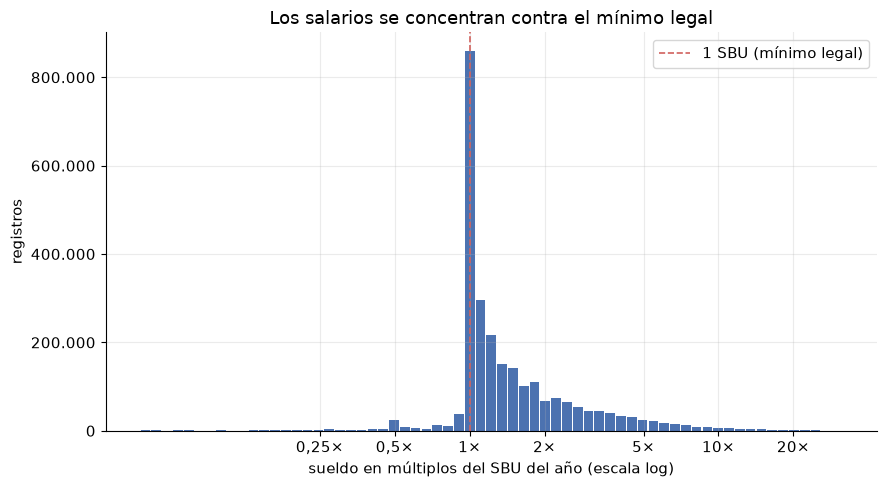

In [5]:
# Distribución del salario (en múltiplos de SBU, escala log) — forma y pico en el mínimo legal
sql_hist = f"""
WITH c AS (SELECT {SUELDO_SBU} AS s FROM {VIEW}
           WHERE es_ultima_version AND sueldo IS NOT NULL AND sueldo > 0 AND cargo IS NOT NULL)
SELECT ROUND(LN(s), 1) AS ln_bucket, COUNT(*) AS n
FROM c WHERE s BETWEEN 0.05 AND 30 GROUP BY 1 ORDER BY 1
"""
dh = q(sql_hist)
fig, ax = plt.subplots()
ax.bar(dh["ln_bucket"], dh["n"], width=0.09, color=C_ACENTO)
ax.axvline(0, ls="--", c=C_AMBIGUA, lw=1.2, label="1 SBU (mínimo legal)")
# Eje x en múltiplos de SBU (posición logarítmica, etiqueta legible)
import math
ticks = [0.25, 0.5, 1, 2, 5, 10, 20]
ax.set_xticks([math.log(t) for t in ticks])
ax.set_xticklabels([f"{t:g}×".replace(".", ",") for t in ticks])
ax.set_xlabel("sueldo en múltiplos del SBU del año (escala log)"); ax.set_ylabel("registros")
ax.set_title("Los salarios se concentran contra el mínimo legal")
ax.legend()
plt.tight_layout(); plt.show()


La distribución es sesgada, con un pico marcado en un salario básico. De aquí salen dos decisiones de método: leer los sueldos en escala logarítmica y en múltiplos del SBU del año (el mínimo subió casi 30% en la década), y recordar que los cargos peor pagados se ven poco dispersos en parte porque la ley les impide bajar del piso.


Ese 40% no está repartido por igual en el tiempo. Conviene mirar cómo evolucionó la captura del cargo a lo largo de la década.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


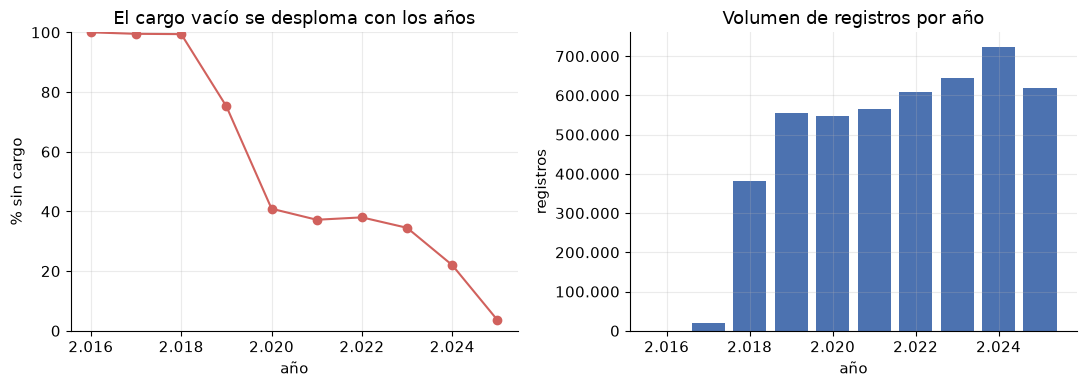

In [6]:
# Evolución temporal: cobertura del cargo y volumen por año
sql_tiempo = f"""
SELECT anio_valoracion AS anio, COUNT(*) AS registros,
  COUNT(DISTINCT empresa_identificacion) AS empresas,
  ROUND(COUNTIF(cargo IS NULL OR TRIM(cargo)="")/COUNT(*)*100,1) AS pct_cargo_vacio
FROM {VIEW} WHERE es_ultima_version = TRUE GROUP BY 1 ORDER BY 1
"""
dt = q(sql_tiempo)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(dt["anio"], dt["pct_cargo_vacio"], marker="o", color=C_AMBIGUA)
axes[0].set_ylim(0, 100); axes[0].set_ylabel("% sin cargo"); axes[0].set_xlabel("año")
axes[0].set_title("El cargo vacío se desploma con los años")
axes[1].bar(dt["anio"], dt["registros"], color=C_ACENTO)
axes[1].set_ylabel("registros"); axes[1].set_xlabel("año")
axes[1].set_title("Volumen de registros por año")
plt.tight_layout(); plt.show()


El 40% global esconde una fuerte tendencia: en los primeros años (2016–2018) el cargo venía casi siempre vacío (~99%), y la captura mejoró hasta quedar casi completa en 2025 (~4% vacío). La ausencia de cargo es, en buena medida, **herencia de los estudios antiguos**; el análisis de la etiqueta se apoya de hecho en los años recientes, donde el cargo sí existe. El problema de fondo —la ambigüedad de la etiqueta *entre empresas*— es independiente del año.


## Consistencia dentro de una misma empresa

El primer test es el más favorable a la etiqueta: mirarla dentro de una sola empresa. Se agrupan las personas que, en la misma empresa y el mismo año, comparten la misma etiqueta de cargo, y se observa qué tan distintos son sus sueldos. Si todos ganan parecido, la etiqueta describe un solo trabajo; si unos ganan poco y otros mucho, está mezclando roles distintos bajo el mismo nombre —"secretaria" para la recepcionista y para la asistente de gerencia, por ejemplo—.

La dispersión se mide con el **coeficiente de variación** (desviación estándar dividida por la media). Dividir por la media es deliberado: pone en términos relativos a un grupo de gerentes (sueldos de miles) y a uno de obreros (de cientos), que de otro modo no serían comparables. Se evalúan solo grupos de al menos tres personas —con una o dos no hay dispersión que medir— y se compara el dato crudo con el limpio para descontar el efecto de la basura.


In [7]:
# Diagnóstico crudo vs limpio (grupos empresa-año-cargo, n>=MIN_GRUPO)
def diagnostico_intra(limpio: bool) -> pd.DataFrame:
    filtro = f"AND {CLEAN_CARGO}" if limpio else ""
    sql = f"""
    WITH base AS (
      SELECT empresa_identificacion, anio_valoracion, {NORM} AS cargo_norm, sueldo, {SUELDO_SBU} AS sueldo_sbu
      FROM {VIEW}
      WHERE es_ultima_version = TRUE AND sueldo IS NOT NULL AND cargo IS NOT NULL
    ),
    clean AS (SELECT * FROM base WHERE sueldo_sbu >= {MIN_SBU} {filtro}),
    grp AS (SELECT COUNT(*) n, AVG(sueldo) media, STDDEV_SAMP(sueldo) sd
            FROM clean GROUP BY empresa_identificacion, anio_valoracion, cargo_norm),
    fl AS (SELECT *, SAFE_DIVIDE(sd,media) cv FROM grp)
    SELECT SUM(n) registros,
           COUNTIF(n>={MIN_GRUPO}) grupos_evaluables,
           COUNTIF(n>={MIN_GRUPO} AND cv>{CV_UMBRAL}) grupos_colapsados,
           ROUND(SUM(IF(n>={MIN_GRUPO} AND cv>{CV_UMBRAL}, n, 0))/SUM(IF(n>={MIN_GRUPO},n,0))*100,1) pct_empleados_colapsados
    FROM fl
    """
    return q(sql)

pd.concat([diagnostico_intra(False).assign(version="crudo"),
           diagnostico_intra(True ).assign(version="limpio")], ignore_index=True)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,registros,grupos_evaluables,grupos_colapsados,pct_empleados_colapsados,version
0,2575862,146364,8538,8.0,crudo
1,2383344,137393,4775,2.7,limpio


Tras descartar rellenos, jubilados y sueldos imposibles, **el 2,7% de las personas** queda en etiquetas que mezclan roles dentro de su propia empresa. Conviene precisar qué es esa cifra: de cada cien personas ubicadas en un grupo evaluable —misma empresa, año y cargo, con al menos tres personas y datos limpios—, unas tres pertenecen a un grupo cuyo coeficiente de variación supera el umbral. Es una cifra de *personas afectadas*, no de etiquetas: podrían ser pocas etiquetas problemáticas pero muy pobladas. Un problema real, aunque minoritario —y, como se verá, apenas un piso—. Como el resultado depende del corte elegido, conviene comprobar su robustez.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Sensibilidad — % empleados en etiquetas colapsadas:


,min_grupo,CV>0.3,CV>0.4,CV>0.5,CV>0.6,CV>0.7
0,3,10.1,5.2,2.6,1.6,1.0
1,5,9.6,4.9,2.5,1.5,1.0
2,10,9.0,4.6,2.3,1.4,1.0


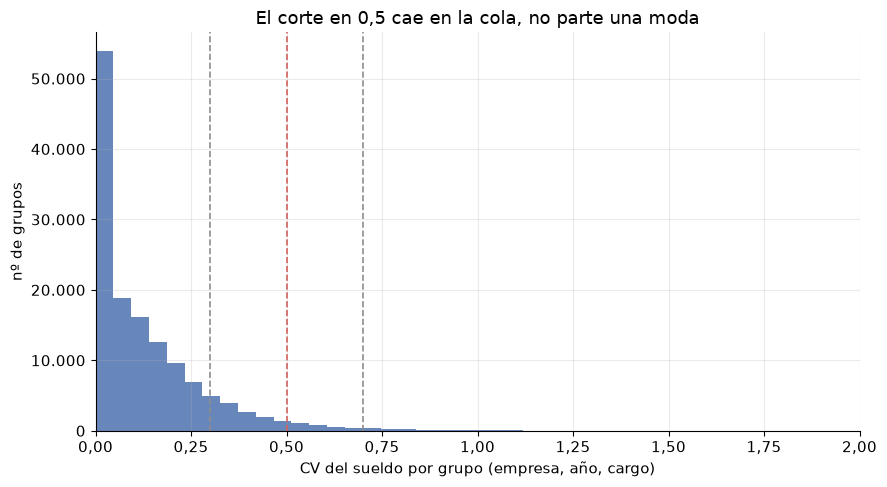

In [8]:
# Distribución del CV intra-grupo + análisis de sensibilidad del umbral y del tamaño mínimo
sql_cv = f"""
WITH base AS (
  SELECT empresa_identificacion, anio_valoracion, {NORM} AS cargo_norm, sueldo, {SUELDO_SBU} AS sueldo_sbu
  FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL
),
clean AS (SELECT * FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO}),
grp AS (SELECT COUNT(*) n, SAFE_DIVIDE(STDDEV_SAMP(sueldo),AVG(sueldo)) cv
        FROM clean GROUP BY empresa_identificacion, anio_valoracion, cargo_norm)
SELECT n, ROUND(cv,3) cv FROM grp WHERE n>={MIN_GRUPO} AND cv IS NOT NULL
"""
gcv = q(sql_cv)

# Sensibilidad: % de empleados colapsados según umbral CV y tamaño mínimo de grupo
filas = []
for mg in (3, 5, 10):
    sub = gcv[gcv["n"] >= mg]
    tot = sub["n"].sum()
    filas.append({"min_grupo": mg, **{f"CV>{u}": round((sub.loc[sub.cv>u,"n"].sum())/tot*100,1) for u in (0.3,0.4,0.5,0.6,0.7)}})
sens = pd.DataFrame(filas);
print("Sensibilidad — % empleados en etiquetas colapsadas:"); display(sens)

fig, ax = plt.subplots()
ax.hist(gcv["cv"], bins=60, color=C_ACENTO, alpha=0.85)
for u,c in [(0.3,C_NEUTRO),(0.5,C_AMBIGUA),(0.7,C_NEUTRO)]:
    ax.axvline(u, ls="--", c=c, lw=1.2)
ax.set_xlim(0,2); ax.set_xlabel("CV del sueldo por grupo (empresa, año, cargo)")
ax.set_ylabel("nº de grupos"); ax.set_title("El corte en 0,5 cae en la cola, no parte una moda")
plt.tight_layout(); plt.show()


El histograma muestra la distribución de esos coeficientes de variación: un pico alto a la izquierda —la mayoría de los grupos, donde un mismo cargo paga parecido— y una cola que se adelgaza hacia la derecha. El umbral de 0,5 cae en esa cola, no sobre el pico, y eso es lo que da robustez a la conclusión: si el corte cayera sobre la acumulación de casos, moverlo un poco haría entrar o salir muchos grupos de golpe; al caer en la cola, moverlo solo cambia la cifra de forma gradual. La tabla de sensibilidad lo confirma —al bajar el umbral a 0,3 la cifra se multiplica, pero de forma suave y monótona, sin saltos—. Lo robusto es la conclusión cualitativa, no el número exacto: **dentro de una empresa el desorden existe, pero es acotado**. Las etiquetas que lo concentran son las esperables:


In [9]:
# Top etiquetas colapsadas (limpio), por empleados afectados
sql_top = f"""
WITH base AS (
  SELECT empresa_identificacion, anio_valoracion, {NORM} AS cargo_norm, sueldo, {SUELDO_SBU} AS sueldo_sbu
  FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL
),
clean AS (SELECT * FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO}),
grp AS (SELECT cargo_norm, COUNT(*) n, SAFE_DIVIDE(STDDEV_SAMP(sueldo),AVG(sueldo)) cv
        FROM clean GROUP BY cargo_norm, empresa_identificacion, anio_valoracion),
fl AS (SELECT * FROM grp WHERE n>={MIN_GRUPO} AND cv>{CV_UMBRAL})
SELECT cargo_norm, COUNT(*) grupos, SUM(n) empleados, ROUND(AVG(cv),2) cv_prom
FROM fl GROUP BY cargo_norm ORDER BY empleados DESC LIMIT 12
"""
q(sql_top)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cargo_norm,grupos,empleados,cv_prom
0,TRABAJADOR AGRICOLA,14,2360,0.69
1,TRABAJADOR EN GENERAL,126,2104,0.72
2,VENDEDOR,226,1895,0.71
3,ADMINISTRATIVO,88,1368,0.74
4,DOCENTE TIEMPO COMPLETO,4,1274,1.23
5,DOCENTE,32,1190,0.62
6,TRABAJADOR ACUICOLA,27,1094,0.66
7,EJECUTIVO DE VENTAS,67,996,0.73
8,ASESOR COMERCIAL,93,899,0.65
9,ASISTENTE ADMINISTRATIVO,120,623,0.68


Encabezan la lista las etiquetas "cajón de sastre" (trabajador en general, administrativo, asistente) y los roles comerciales (vendedor, asesor comercial): cargos genéricos que caben en cualquier empresa y describen poco.


Una duda razonable sobre ese 3%: ¿la etiqueta mezcla roles distintos, o simplemente gente con distinta antigüedad en el mismo puesto? Se separa recomputando el colapso pero agrupando también por banda de antigüedad (años desde el ingreso).


In [10]:
# ¿Cuánto del colapso intra-empresa es antigüedad y cuánto es un artefacto de trocear?
# Se compara: sin control · partiendo por banda de antigüedad · partiendo por banda ALEATORIA (placebo).
sql_tenure = f"""
WITH base AS (
  SELECT empresa_identificacion emp, anio_valoracion anio, CAST(identificacion_persona AS STRING) ced,
    {NORM} AS cargo_norm, sueldo, {SUELDO_SBU} AS sueldo_sbu,
    anio_valoracion - EXTRACT(YEAR FROM COALESCE(fecha_ingreso_desahucio, fecha_ingreso_jubilacion)) AS tenure
  FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL
),
clean AS (SELECT * FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO} AND tenure BETWEEN 0 AND 50),
band AS (SELECT *, CASE WHEN tenure<2 THEN 1 WHEN tenure<5 THEN 2 WHEN tenure<10 THEN 3 ELSE 4 END tb,
                MOD(ABS(FARM_FINGERPRINT(ced)),4) pb FROM clean),
g_sin AS (SELECT COUNT(*) n, SAFE_DIVIDE(STDDEV_SAMP(sueldo),AVG(sueldo)) cv FROM band GROUP BY emp,anio,cargo_norm),
g_ant AS (SELECT COUNT(*) n, SAFE_DIVIDE(STDDEV_SAMP(sueldo),AVG(sueldo)) cv FROM band GROUP BY emp,anio,cargo_norm,tb),
g_pla AS (SELECT COUNT(*) n, SAFE_DIVIDE(STDDEV_SAMP(sueldo),AVG(sueldo)) cv FROM band GROUP BY emp,anio,cargo_norm,pb)
SELECT
  (SELECT ROUND(SUM(IF(n>={MIN_GRUPO} AND cv>{CV_UMBRAL},n,0))/SUM(IF(n>={MIN_GRUPO},n,0))*100,1) FROM g_sin) AS sin_control,
  (SELECT ROUND(SUM(IF(n>={MIN_GRUPO} AND cv>{CV_UMBRAL},n,0))/SUM(IF(n>={MIN_GRUPO},n,0))*100,1) FROM g_ant) AS control_antiguedad,
  (SELECT ROUND(SUM(IF(n>={MIN_GRUPO} AND cv>{CV_UMBRAL},n,0))/SUM(IF(n>={MIN_GRUPO},n,0))*100,1) FROM g_pla) AS particion_aleatoria_placebo
"""
q(sql_tenure)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sin_control,control_antiguedad,particion_aleatoria_placebo
0,2.7,1.9,2.2


Aquí hay que ser cuidadoso: **partir los grupos en bandas reduce la dispersión por sí solo** —grupos más pequeños dispersan menos—, así que hace falta un placebo. Una partición en cuatro bandas *aleatorias* ya baja el colapso de 2,7% a **2,2%** por puro efecto de trocear; la partición por antigüedad lo lleva a **1,9%**. De los 0,8 puntos de caída, la mayor parte es artefacto de partición y solo **~0,3 puntos son antigüedad real** (y es un piso: las bandas de antigüedad son desiguales, lo que exagera algo el componente mecánico). La antigüedad influye, pero mucho menos de lo que sugeriría la resta simple: descontada, el colapso por rol se mantiene alto, en torno al **2,4%**.

Con eso, el desorden dentro de una empresa queda establecido como real pero acotado. El problema cambia de escala al comparar la misma etiqueta entre empresas.


## Consistencia entre empresas

El benchmarking no compara dentro de una empresa: junta la misma etiqueta de miles de empresas para estimar el sueldo de mercado de un cargo. Dos síntomas muestran que ahí la etiqueta se rompe. El primero es la proliferación de variantes:


In [11]:
# Fragmentación y concentración de etiquetas
sql_conc = f"""
WITH base AS (SELECT {NORM} AS cargo_norm, {SUELDO_SBU} AS sueldo_sbu
              FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL),
clean AS (SELECT cargo_norm FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO}),
lab AS (SELECT cargo_norm, COUNT(*) n FROM clean GROUP BY 1),
r AS (SELECT n, ROW_NUMBER() OVER(ORDER BY n DESC) rk, SUM(n) OVER() tot FROM lab)
SELECT MAX(rk) etiquetas_distintas, MAX(tot) empleados,
  ROUND(SUM(IF(rk<=20,n,0))/MAX(tot)*100,1) pct_top20,
  ROUND(SUM(IF(rk<=100,n,0))/MAX(tot)*100,1) pct_top100
FROM r
"""
q(sql_conc)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,etiquetas_distintas,empleados,pct_top20,pct_top100
0,100832,2383344,17.1,32.8


Conviven dos patologías opuestas: **una fragmentación enorme** —cerca de cien mil formas distintas de escribir un cargo, y es una cota superior porque ni siquiera se unifican plurales o sinónimos— y, a la vez, **una concentración fuerte**, ya que apenas un centenar de etiquetas genéricas cubre alrededor de un tercio de la población. Una cola larguísima de cargos casi únicos junto a un puñado de cajones de sastre que absorben todo lo demás.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


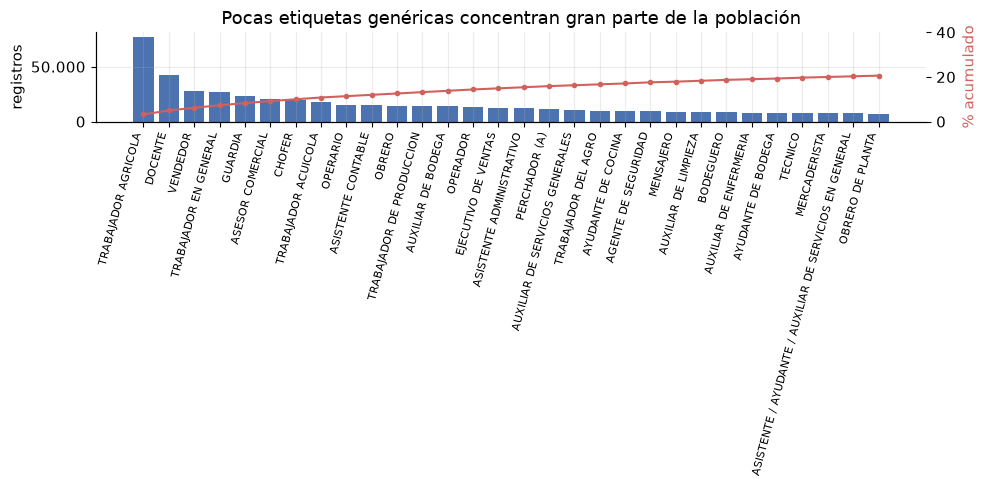

In [12]:
# Curva de Pareto de las etiquetas (top 30) con % acumulado
sql_par = f"""
WITH base AS (SELECT {NORM} AS cargo_norm, {SUELDO_SBU} AS sueldo_sbu
              FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL),
clean AS (SELECT cargo_norm FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO}),
lab AS (SELECT cargo_norm, COUNT(*) n FROM clean GROUP BY 1),
r AS (SELECT cargo_norm, n, SUM(n) OVER() tot, ROW_NUMBER() OVER(ORDER BY n DESC) rk FROM lab)
SELECT cargo_norm, n, ROUND(SUM(n) OVER(ORDER BY rk)/tot*100,1) cum_pct
FROM r WHERE rk<=30 ORDER BY n DESC
"""
dp = q(sql_par)
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(range(len(dp)), dp["n"], color=C_ACENTO)
ax.set_xticks(range(len(dp))); ax.set_xticklabels(dp["cargo_norm"], rotation=75, ha="right", fontsize=8)
ax.set_ylabel("registros"); ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(range(len(dp)), dp["cum_pct"], color=C_AMBIGUA, marker="o", ms=3)
ax2.set_ylabel("% acumulado", color=C_AMBIGUA); ax2.set_ylim(0, 40)
ax.set_title("Pocas etiquetas genéricas concentran gran parte de la población")
plt.tight_layout(); plt.show()


El segundo síntoma es el decisivo: cuánto varía el sueldo de una misma etiqueta entre empresas. Se calcula el sueldo promedio de cada cargo por empresa —exigiendo al menos tres personas por empresa para que el promedio sea estable— y se mide su dispersión entre empresas, todo en múltiplos del salario mínimo:


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


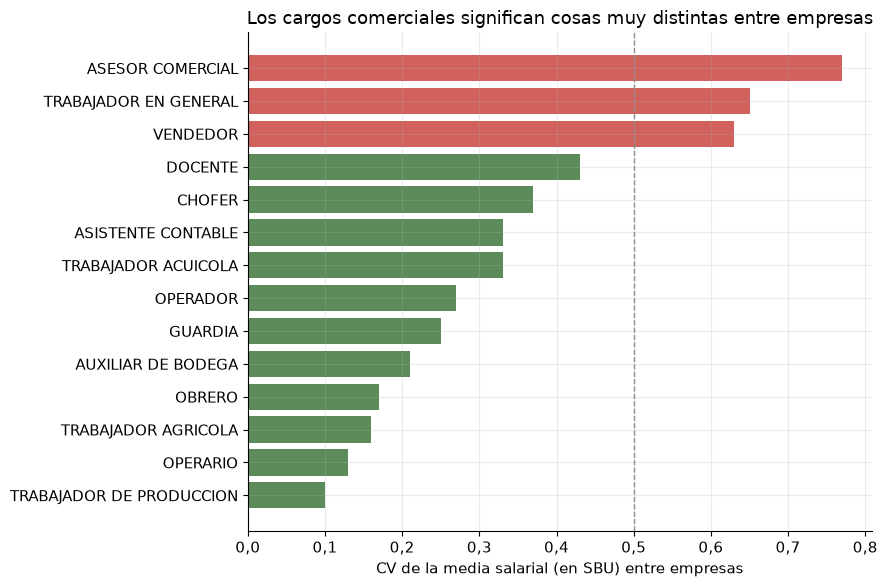

,cargo_norm,empresas,media_sbu,cv_cross,p10_sbu,p90_sbu
0,ASESOR COMERCIAL,417,1.73,0.77,1.03,2.80
1,TRABAJADOR EN GENERAL,818,1.25,0.65,0.99,1.66
2,VENDEDOR,860,1.62,0.63,1.02,2.61
3,DOCENTE,227,1.67,0.43,1.03,2.38
4,CHOFER,1342,1.40,0.37,1.04,1.71
5,ASISTENTE CONTABLE,1627,1.58,0.33,1.10,2.17
6,TRABAJADOR ACUICOLA,169,1.15,0.33,1.01,1.33
7,OPERADOR,219,1.27,0.27,1.00,1.73
8,GUARDIA,443,1.15,0.25,1.00,1.45
9,AUXILIAR DE BODEGA,517,1.15,0.21,1.01,1.39


In [13]:
# Dispersión CROSS-empresa: CV de la media (en SBU) por empresa, exigiendo n>=MIN_GRUPO por empresa
sql_cross = f"""
WITH base AS (SELECT empresa_identificacion, {NORM} AS cargo_norm, {SUELDO_SBU} AS sueldo_sbu
              FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL),
clean AS (SELECT * FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO}),
per_emp AS (SELECT cargo_norm, empresa_identificacion, AVG(sueldo_sbu) media_emp, COUNT(*) n
            FROM clean GROUP BY 1,2 HAVING COUNT(*) >= {MIN_GRUPO}),
freq AS (SELECT cargo_norm, SUM(n) tot FROM per_emp GROUP BY 1 ORDER BY tot DESC LIMIT 14)
SELECT p.cargo_norm,
  COUNT(DISTINCT p.empresa_identificacion) empresas,
  ROUND(AVG(p.media_emp),2) media_sbu,
  ROUND(SAFE_DIVIDE(STDDEV_SAMP(p.media_emp),AVG(p.media_emp)),2) cv_cross,
  ROUND(APPROX_QUANTILES(p.media_emp,100)[OFFSET(10)],2) p10_sbu,
  ROUND(APPROX_QUANTILES(p.media_emp,100)[OFFSET(90)],2) p90_sbu
FROM per_emp p JOIN freq f USING(cargo_norm)
GROUP BY 1 ORDER BY cv_cross DESC
"""
dc = q(sql_cross)
fig, ax = plt.subplots(figsize=(9,6))
cols = [C_AMBIGUA if v>0.5 else C_CONSIST for v in dc["cv_cross"]]
ax.barh(dc["cargo_norm"], dc["cv_cross"], color=cols)
ax.axvline(0.5, ls="--", c=C_NEUTRO, lw=1)
ax.invert_yaxis(); ax.set_xlabel("CV de la media salarial (en SBU) entre empresas")
ax.set_title("Los cargos comerciales significan cosas muy distintas entre empresas")
plt.tight_layout(); plt.show()
dc


**Hay dos mundos.** Cargos como operario, obrero, trabajador agrícola o guardia apenas varían entre empresas: se apiñan cerca de un salario básico, son roles regulados y homogéneos, y para ellos comparar por etiqueta funcionaría. En cambio, los comerciales —asesor comercial, vendedor, ejecutivo de ventas— y el genérico "trabajador en general" van desde alrededor de un salario básico en unas empresas hasta casi tres en otras: la etiqueta no describe el trabajo, y promediar sobre ella no representa a nadie. La distribución completa lo confirma:


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
C:\Users\pablo.encalada_actua\AppData\Local\Temp\ipykernel_33392\3662189497.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  res = ax.bxp(stats, vert=False, showfliers=False, patch_artist=True)


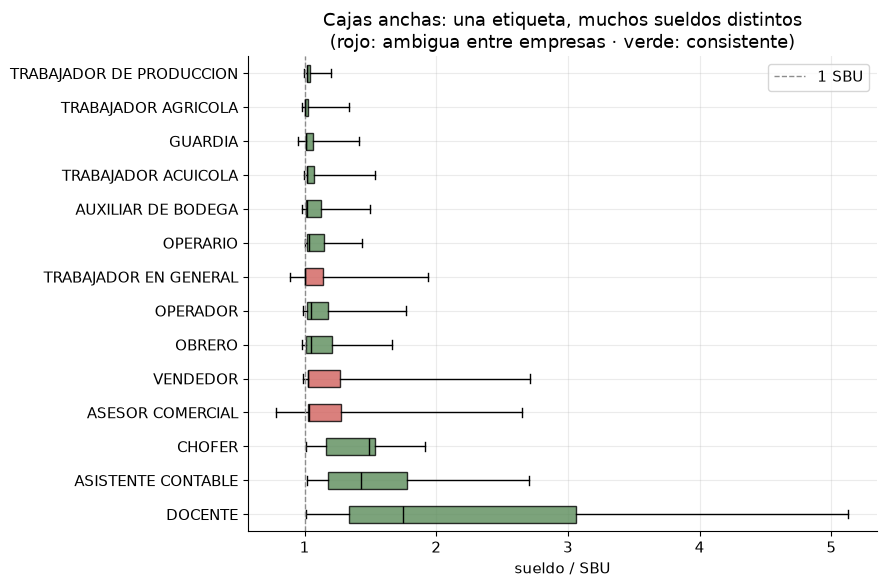

In [14]:
# Boxplots (desde cuantiles, respeta privacidad) del salario en SBU para las etiquetas del ranking
sql_box = f"""
WITH base AS (SELECT {NORM} AS cargo_norm, {SUELDO_SBU} AS sueldo_sbu
              FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL),
clean AS (SELECT * FROM base WHERE sueldo_sbu >= {MIN_SBU} AND {CLEAN_CARGO}),
freq AS (SELECT cargo_norm, COUNT(*) n FROM clean GROUP BY 1 ORDER BY n DESC LIMIT 14)
SELECT c.cargo_norm,
  APPROX_QUANTILES(sueldo_sbu,100)[OFFSET(5)]  p5,
  APPROX_QUANTILES(sueldo_sbu,100)[OFFSET(25)] p25,
  APPROX_QUANTILES(sueldo_sbu,100)[OFFSET(50)] p50,
  APPROX_QUANTILES(sueldo_sbu,100)[OFFSET(75)] p75,
  APPROX_QUANTILES(sueldo_sbu,100)[OFFSET(95)] p95
FROM clean c JOIN freq f USING(cargo_norm) GROUP BY 1 ORDER BY (p75-p25) DESC
"""
db = q(sql_box)
stats = [{"label": r.cargo_norm, "whislo": r.p5, "q1": r.p25, "med": r.p50,
          "q3": r.p75, "whishi": r.p95, "fliers": []} for r in db.itertuples()]
fig, ax = plt.subplots(figsize=(9,6))
res = ax.bxp(stats, vert=False, showfliers=False, patch_artist=True)
# Colorear con el MISMO criterio que la barra de CV cross-empresa (dc): rojo si CV>0,5
cvmap = dict(zip(dc["cargo_norm"], dc["cv_cross"]))
for box, r in zip(res["boxes"], db.itertuples()):
    cv = cvmap.get(r.cargo_norm)
    amb = (cv > 0.5) if cv is not None else (((r.p75 - r.p25)/r.p50 > 0.5) if r.p50 else False)
    box.set_facecolor(C_AMBIGUA if amb else C_CONSIST); box.set_alpha(0.8)
for med in res["medians"]:
    med.set_color("black")
ax.axvline(1, ls="--", c=C_NEUTRO, lw=1, label="1 SBU")
ax.set_xlabel("sueldo / SBU")
ax.set_title("Cajas anchas: una etiqueta, muchos sueldos distintos\n(rojo: ambigua entre empresas · verde: consistente)")
ax.legend(); plt.tight_layout(); plt.show()


Las etiquetas ambiguas son cajas anchas; las estandarizadas, cajas estrechas pegadas al mínimo. Es la misma evidencia del coeficiente de variación, ahora visible como forma.


Queda una objeción de fondo: quizá esa variación entre empresas no sea ambigüedad de la etiqueta, sino que un mismo cargo pertenece a sectores distintos —un asesor comercial de banca no es uno de agroindustria—. Se puede medir directamente: de toda la variación del sueldo de una etiqueta entre empresas, ¿qué fracción explica el sector (CIIU)?


In [15]:
# ¿Cuánto de la dispersión cross-empresa explica el sector?
sql_sector = f"""
WITH j AS (
  SELECT empresa_identificacion emp, b.ciiu_n1 ciiu, {NORM} cargo_norm, {SUELDO_SBU} s_sbu
  FROM {VIEW} e
  JOIN (SELECT ruc, ciiu_n1, ROW_NUMBER() OVER(PARTITION BY ruc ORDER BY anio DESC) rn
        FROM {BAL} WHERE ciiu_n1 IS NOT NULL) b
    ON e.empresa_identificacion = b.ruc AND b.rn = 1
  WHERE e.es_ultima_version AND e.sueldo IS NOT NULL AND e.cargo IS NOT NULL AND {SUELDO_SBU} >= {MIN_SBU}
),
clean AS (SELECT * FROM j WHERE {CLEAN_CARGO}),
per_emp AS (SELECT cargo_norm, emp, ANY_VALUE(ciiu) ciiu, AVG(s_sbu) me, COUNT(*) n
            FROM clean GROUP BY 1,2 HAVING COUNT(*) >= {MIN_GRUPO}),
freq AS (SELECT cargo_norm, SUM(n) t FROM per_emp GROUP BY 1 ORDER BY t DESC LIMIT 12),
pe AS (SELECT p.* FROM per_emp p JOIN freq f USING(cargo_norm)),
lab AS (SELECT cargo_norm, AVG(me) gm, COUNT(*) N, SUM(me*me) sm2 FROM pe GROUP BY 1),
sec AS (SELECT cargo_norm, SUM(POW(s,2)/n) ssb
        FROM (SELECT cargo_norm, ciiu, SUM(me) s, COUNT(*) n FROM pe GROUP BY 1,2) GROUP BY 1)
SELECT l.cargo_norm, l.N AS empresas,
  ROUND(SQRT((l.sm2 - l.N*l.gm*l.gm)/l.N)/l.gm, 2)            AS cv_entre_empresas,
  ROUND((sec.ssb - l.N*l.gm*l.gm)/(l.sm2 - l.N*l.gm*l.gm), 2) AS fraccion_explica_sector
FROM lab l JOIN sec USING(cargo_norm) ORDER BY cv_entre_empresas DESC
"""
q(sql_sector)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cargo_norm,empresas,cv_entre_empresas,fraccion_explica_sector
0,ASESOR COMERCIAL,330,0.83,0.02
1,TRABAJADOR EN GENERAL,556,0.74,0.04
2,EJECUTIVO DE VENTAS,205,0.68,0.29
3,VENDEDOR,685,0.62,0.03
4,TRABAJADOR ACUICOLA,101,0.40,0.00
5,GUARDIA,284,0.27,0.04
6,CHOFER,952,0.22,0.05
7,AUXILIAR DE BODEGA,392,0.22,0.06
8,OBRERO,136,0.17,0.19
9,TRABAJADOR AGRICOLA,150,0.14,0.26


**El sector casi no explica la ambigüedad.** En los cargos comerciales genéricos —asesor comercial, vendedor, trabajador en general— el sector da cuenta de menos del 5% de su variación entre empresas: no es que sean sectores distintos, es que la etiqueta no describe el trabajo. La excepción es *ejecutivo de ventas*, donde el sector sí pesa (~30%). En los cargos estandarizados el sector a veces explica una fracción mayor, pero su variación total es tan baja que resulta irrelevante. Se usa el nivel más grueso de CIIU (sección, ~18 ramas), así que ese <5% es una **cota inferior** —con un sector más fino explicaría algo más—, pero difícilmente cambiaría el orden de magnitud. Con esto se descarta la explicación sectorial: el hallazgo central queda en pie.


## Tamaño de empresa y validez externa

Una objeción razonable: quizá la dispersión no venga de la etiqueta sino de que unas empresas pagan más que otras. Para responderla hay que reconocer primero un límite de la muestra, porque condiciona toda generalización: estas son empresas que **encargan estudios actuariales**, típicamente formales, maduras y grandes.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,% universo,% muestra
segmento,,
MICROEMPRESA,73.7,14.0
PEQUEÑA,18.6,28.6
MEDIANA,5.4,30.4
GRANDE,2.2,27.1


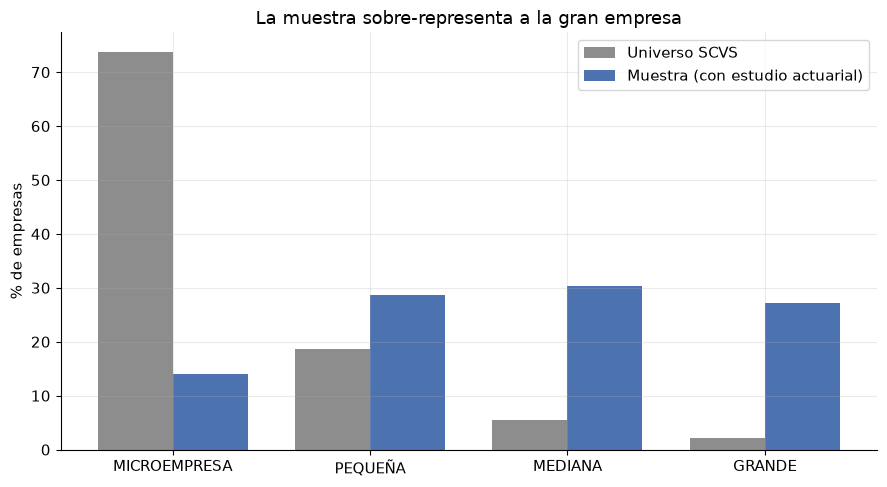

In [16]:
# Sesgo de selección: distribución de empresas por segmento — muestra vs universo SCVS
sql_uni = f"""
WITH bal AS (SELECT ruc, segmento, ROW_NUMBER() OVER(PARTITION BY ruc ORDER BY anio DESC) rn
             FROM {BAL} WHERE segmento IS NOT NULL)
SELECT segmento, COUNT(*) universo FROM bal WHERE rn=1 GROUP BY 1
"""
sql_mue = f"""
WITH est AS (SELECT DISTINCT empresa_identificacion FROM {VIEW} WHERE es_ultima_version),
bal AS (SELECT ruc, segmento, ROW_NUMBER() OVER(PARTITION BY ruc ORDER BY anio DESC) rn
        FROM {BAL} WHERE segmento IS NOT NULL)
SELECT b.segmento, COUNT(*) muestra
FROM est e JOIN (SELECT * FROM bal WHERE rn=1) b ON e.empresa_identificacion=b.ruc
GROUP BY 1
"""
sel = q(sql_uni).merge(q(sql_mue), on="segmento")
orden = ["MICROEMPRESA","PEQUEÑA","MEDIANA","GRANDE"]
sel = sel.set_index("segmento").reindex(orden)
sel["% universo"] = (sel["universo"]/sel["universo"].sum()*100).round(1)
sel["% muestra"]  = (sel["muestra"]/sel["muestra"].sum()*100).round(1)
display(sel[["% universo","% muestra"]])

x = np.arange(len(orden)); w = 0.38
fig, ax = plt.subplots()
ax.bar(x-w/2, sel["% universo"], w, label="Universo SCVS", color=C_NEUTRO)
ax.bar(x+w/2, sel["% muestra"],  w, label="Muestra (con estudio actuarial)", color=C_ACENTO)
ax.set_xticks(x); ax.set_xticklabels(orden); ax.set_ylabel("% de empresas")
ax.set_title("La muestra sobre-representa a la gran empresa")
ax.legend(); plt.tight_layout(); plt.show()


**La gran empresa es apenas un 2% del universo de compañías registradas pero llega al 27% de la muestra**; la microempresa, que domina el universo, casi desaparece. Esto fija el alcance honesto del análisis: representa al empleo formal privado de empresas medianas y grandes, no al mercado laboral completo, y deja fuera la informalidad, el sector público y la pequeña empresa. Es la principal limitación del trabajo. El sesgo probablemente va más allá del tamaño: como la jubilación patronal se devenga cerca de los 25 años de servicio, la muestra tiende también a empresas con **fuerzas laborales de mayor antigüedad**, lo que puede elevar algo los niveles salariales observados y la distribución de tenure usada en el control de antigüedad.

Con esa advertencia, la objeción del tamaño se contrasta fijando el cargo y comparando su sueldo mediano entre segmentos de empresa — en varios cargos específicos, poblados y presentes en los cuatro segmentos (para no confundir el efecto tamaño con la ambigüedad de las etiquetas genéricas):


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cargo_norm,micro,pequena,mediana,grande,ratio_grande_pequena,n_total
0,CHOFER,1.31,1.50,1.49,1.47,0.98,14228
1,ASISTENTE CONTABLE,1.42,1.33,1.41,1.49,1.12,10922
2,ASISTENTE ADMINISTRATIVO,1.30,1.29,1.28,1.26,0.97,8761
3,DOCENTE,1.37,1.30,1.50,1.67,1.28,5853
4,SUPERVISOR,1.75,1.41,1.42,1.38,0.98,5201
5,ASISTENTE ADMINISTRATIVA,1.41,1.27,1.33,1.30,1.03,4555
6,MECANICO,1.41,1.27,1.55,1.38,1.08,4325
7,GERENTE GENERAL,3.75,3.75,6.35,10.00,2.67,3710
8,ASISTENTE,1.38,1.20,1.25,1.26,1.05,3268
9,CONTADOR,3.17,2.35,2.75,3.45,1.47,2894


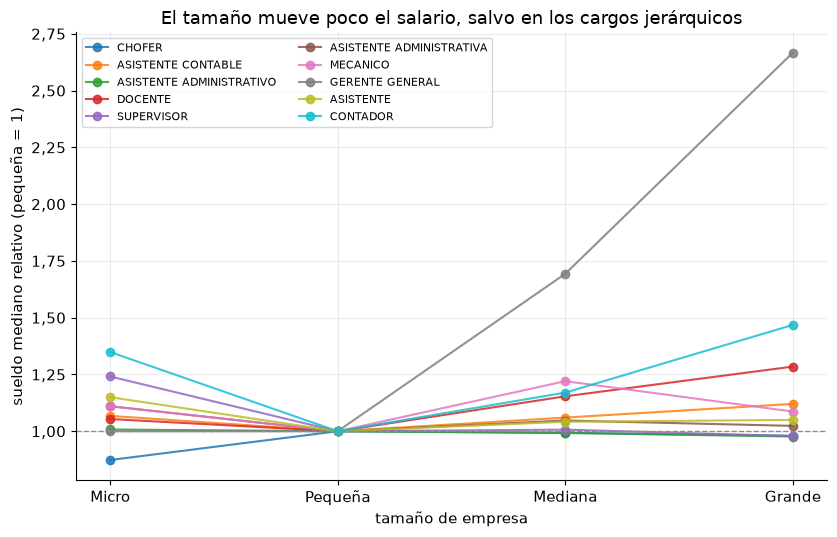

In [17]:
# Efecto del tamaño de empresa en varios cargos específicos (mediana en SBU por segmento)
sql_seg = f"""
WITH base AS (SELECT empresa_identificacion emp, {NORM} cargo_norm, {SUELDO_SBU} s
              FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL AND {SUELDO_SBU} >= {MIN_SBU}),
clean AS (SELECT * FROM base WHERE {CLEAN_CARGO}),
bal AS (SELECT ruc, segmento, ROW_NUMBER() OVER(PARTITION BY ruc ORDER BY anio DESC) rn FROM {BAL} WHERE segmento IS NOT NULL),
j AS (SELECT c.cargo_norm,
   CASE WHEN bal.segmento LIKE 'MICRO%' THEN 'micro' WHEN bal.segmento LIKE 'PEQUE%' THEN 'pequena'
        WHEN bal.segmento LIKE 'MEDIAN%' THEN 'mediana' WHEN bal.segmento LIKE 'GRAND%' THEN 'grande' END seg, c.s
   FROM clean c JOIN (SELECT * FROM bal WHERE rn=1) bal ON c.emp=bal.ruc),
g AS (SELECT cargo_norm, seg, APPROX_QUANTILES(s,100)[OFFSET(50)] med, COUNT(*) n FROM j WHERE seg IS NOT NULL GROUP BY 1,2),
piv AS (SELECT cargo_norm,
   MAX(IF(seg='micro',med,NULL)) micro, MAX(IF(seg='pequena',med,NULL)) pequena,
   MAX(IF(seg='mediana',med,NULL)) mediana, MAX(IF(seg='grande',med,NULL)) grande,
   MAX(IF(seg='micro',n,0)) nmi, MAX(IF(seg='pequena',n,0)) npe, MAX(IF(seg='mediana',n,0)) nme, MAX(IF(seg='grande',n,0)) ngr, SUM(n) n_total
   FROM g GROUP BY 1)
SELECT cargo_norm, ROUND(micro,2) micro, ROUND(pequena,2) pequena, ROUND(mediana,2) mediana, ROUND(grande,2) grande,
   ROUND(grande/pequena,2) ratio_grande_pequena, n_total
FROM piv
WHERE nmi>=30 AND npe>=30 AND nme>=30 AND ngr>=30 AND grande>=1.2
ORDER BY n_total DESC LIMIT 10
"""
dseg = q(sql_seg)
display(dseg)

# Cada cargo: sueldo mediano por tamaño, normalizado a "pequeña"=1 -> la pendiente es el efecto tamaño
cols, etiq = ["micro","pequena","mediana","grande"], ["Micro","Pequeña","Mediana","Grande"]
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for row in dseg.itertuples():
    ax.plot(etiq, [getattr(row, c)/row.pequena for c in cols], marker="o", lw=1.5, alpha=0.85, label=row.cargo_norm)
ax.axhline(1, ls="--", c=C_NEUTRO, lw=1)
ax.set_ylabel("sueldo mediano relativo (pequeña = 1)"); ax.set_xlabel("tamaño de empresa")
ax.set_title("El tamaño mueve poco el salario, salvo en los cargos jerárquicos")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


**El tamaño importa, pero de forma desigual.** En la mayoría de los cargos —operativos, administrativos, técnicos— el sueldo apenas cambia con el tamaño de la empresa: las líneas son casi planas (chofer, asistente administrativo o supervisor rondan el ratio 1,0; asistente contable ~1,1). El efecto se concentra en los **cargos jerárquicos**: un contador gana ~1,5× más en una empresa grande que en una pequeña, y un gerente general hasta ~2,7× (de ~3,8 a ~10 SBU). Como esos cargos altos son una minoría, en el agregado el tamaño explica muy poca varianza —el 0,1% que veremos enseguida—, aunque para ellos sí sea decisivo. Y hay un matiz que refuerza la tesis: parte de esa prima en los cargos altos *es* la misma ambigüedad — un "gerente general" de una microempresa y uno de una gran corporación no son el mismo trabajo con distinto pago, sino títulos que designan trabajos distintos. La conclusión se mantiene: conviene segmentar por tamaño (sobre todo en los cargos altos), pero el factor dominante de la dispersión sigue siendo **qué significa la etiqueta**, no el tamaño del empleador.


Para cerrar, una mirada de conjunto: ¿qué factores explican la varianza del salario? Se descompone el log-sueldo calculando, por factor, dos medidas: el **η²** (varianza explicada) y el **ω²** (la misma, ajustada por grados de libertad, que penaliza a los factores con muchos niveles). Sobre el subconjunto con datos de empresa.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,factor,niveles,eta2,omega2
0,etiqueta de cargo,75512,0.749,0.737
1,empresa,6340,0.343,0.340
2,sector (CIIU),18,0.061,0.061
3,provincia,23,0.014,0.014
4,año,9,0.007,0.007
5,tamaño,4,0.001,0.001


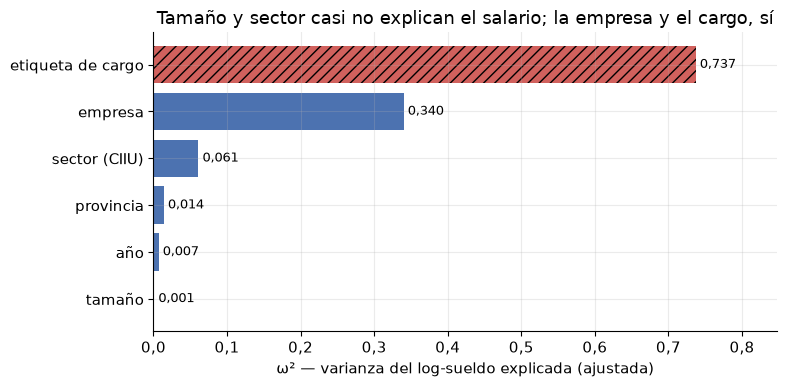

In [18]:
# Descomposición de varianza del log-sueldo: eta^2 y omega^2 (ajustado) por factor
sql_var = f"""
WITH j AS (
  SELECT LN({SUELDO_SBU}) y, {NORM} cargo_norm, empresa_identificacion emp,
         SUBSTR(CAST(empresa_identificacion AS STRING),1,2) prov,
         CAST(anio_valoracion AS STRING) anio, b.ciiu_n1 ciiu, b.segmento seg
  FROM {VIEW} e
  JOIN (SELECT ruc, ciiu_n1, segmento, ROW_NUMBER() OVER(PARTITION BY ruc ORDER BY anio DESC) rn
        FROM {BAL} WHERE segmento IS NOT NULL AND ciiu_n1 IS NOT NULL) b
    ON e.empresa_identificacion = b.ruc AND b.rn = 1
  WHERE e.es_ultima_version AND e.sueldo IS NOT NULL AND e.cargo IS NOT NULL AND {SUELDO_SBU} >= {MIN_SBU}
),
base AS (SELECT * FROM j WHERE {CLEAN_CARGO}),
t AS (SELECT AVG(y) gm, COUNT(*) N, SUM(y*y) sy2 FROM base)
SELECT t.gm, t.N, t.sy2,
  (SELECT SUM(POW(s,2)/n) FROM (SELECT SUM(y) s,COUNT(*) n FROM base GROUP BY cargo_norm)) b_cargo, (SELECT COUNT(DISTINCT cargo_norm) FROM base) k_cargo,
  (SELECT SUM(POW(s,2)/n) FROM (SELECT SUM(y) s,COUNT(*) n FROM base GROUP BY emp))        b_empresa, (SELECT COUNT(DISTINCT emp) FROM base) k_empresa,
  (SELECT SUM(POW(s,2)/n) FROM (SELECT SUM(y) s,COUNT(*) n FROM base GROUP BY ciiu))       b_sector, (SELECT COUNT(DISTINCT ciiu) FROM base) k_sector,
  (SELECT SUM(POW(s,2)/n) FROM (SELECT SUM(y) s,COUNT(*) n FROM base GROUP BY seg))        b_tamano, (SELECT COUNT(DISTINCT seg) FROM base) k_tamano,
  (SELECT SUM(POW(s,2)/n) FROM (SELECT SUM(y) s,COUNT(*) n FROM base GROUP BY anio))       b_anio,  (SELECT COUNT(DISTINCT anio) FROM base) k_anio,
  (SELECT SUM(POW(s,2)/n) FROM (SELECT SUM(y) s,COUNT(*) n FROM base GROUP BY prov))       b_prov,  (SELECT COUNT(DISTINCT prov) FROM base) k_prov
FROM t
"""
r = q(sql_var).iloc[0]
N, gm, sy2 = float(r["N"]), float(r["gm"]), float(r["sy2"])
sst = sy2 - N*gm*gm
filas = []
for f, lbl in [("cargo","etiqueta de cargo"),("empresa","empresa"),("sector","sector (CIIU)"),("prov","provincia"),("tamano","tamaño"),("anio","año")]:
    k = int(r[f"k_{f}"]); ssb = float(r[f"b_{f}"]) - N*gm*gm
    msw = (sst - ssb)/(N - k)
    filas.append({"factor": lbl, "niveles": k,
                  "eta2": round(ssb/sst, 3),
                  "omega2": round((ssb - (k-1)*msw)/(sst + msw), 3)})
dv = pd.DataFrame(filas).sort_values("omega2", ascending=False).reset_index(drop=True)
display(dv)

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(dv["factor"], dv["omega2"],
                 color=[C_AMBIGUA if f == "etiqueta de cargo" else C_ACENTO for f in dv["factor"]])
for bar, f in zip(barras, dv["factor"]):
    if f == "etiqueta de cargo":
        bar.set_hatch("///")
ax.bar_label(barras, labels=[f"{v:.3f}".replace(".", ",") for v in dv["omega2"]], padding=3, fontsize=9)
ax.set_xlim(0, max(dv["omega2"]) * 1.15)
ax.invert_yaxis(); ax.set_xlabel("ω² — varianza del log-sueldo explicada (ajustada)")
ax.set_title("Tamaño y sector casi no explican el salario; la empresa y el cargo, sí")
plt.tight_layout(); plt.show()


El tamaño de la empresa explica apenas un **0,1%** de la varianza del salario, el sector un **6%** y la provincia un **1,4%**: los ejes con que suele segmentarse un benchmark —tamaño, sector, geografía— casi no mueven la aguja (son medidas marginales que se solapan, así que no se suman). La empresa individual explica un tercio —el pago es en buena parte idiosincrático de cada empleador— y la etiqueta de cargo un 75%. Podría temerse que esos dos estén inflados por su gran número de niveles (cargo ~75 mil en este subconjunto con datos de empresa —del orden de las ~100 mil del total—, empresa ~6 mil), pero el ω² (Hays, 1994), que castiga justamente esa cardinalidad, resulta **casi idéntico al η²** (cargo 0,74; empresa 0,34): con 1,7 millones de registros el inflado es despreciable. El 75% del cargo no significa que la etiqueta sea confiable —describe bien *cuando existe y es específica*, y falla en las genéricas de alto volumen y en el 40% donde no existe.


## Composición salarial: lo que aún no se puede medir

Para agrupar por *tipo de trabajo* y no por *nivel de ingreso* haría falta describir cómo se compone el salario: cuánto es fijo, cuánto comisiones, cuánto horas extras. Esa composición separa a un vendedor a comisión de un administrativo a sueldo fijo mejor que el monto total, y evita un problema de fondo: agrupar usando el salario para luego medir el salario sería un razonamiento circular. El inconveniente es que los estudios actuariales no traen ese desglose; solo el sueldo base y un promedio actuarial. Se evalúa si la diferencia entre ambos sirve como aproximación de la parte variable:


In [19]:
sql_comp = f"""
WITH b AS (SELECT sueldo, COALESCE(remuneracion_promedio_desahucio, remuneracion_promedio_jubilacion) rp,
                  {SUELDO_SBU} AS sueldo_sbu
           FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL),
r AS (SELECT SAFE_DIVIDE(rp - sueldo, rp) pv FROM b WHERE sueldo_sbu >= {MIN_SBU} AND rp > 0)
SELECT ROUND(COUNTIF(pv < -0.05)/COUNT(*)*100,1) pct_rp_menor_sueldo,
       ROUND(COUNTIF(pv BETWEEN -0.05 AND 0.05)/COUNT(*)*100,1) pct_casi_igual,
       ROUND(COUNTIF(pv > 0.05)/COUNT(*)*100,1) pct_rp_mayor
FROM r
"""
q(sql_comp)


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,pct_rp_menor_sueldo,pct_casi_igual,pct_rp_mayor
0,10.5,34.1,55.4


**La aproximación no sirve como sustituto limpio.** En una fracción no despreciable de casos el promedio actuarial es menor que el sueldo actual —imposible si fuera remuneración total—, porque se calcula sobre el historial y los sueldos suben con el tiempo; la diferencia mezcla crecimiento salarial con componente variable.

Esto obliga a matizar el hallazgo entre empresas: en los roles a comisión, medir solo el sueldo base puede exagerar la ambigüedad, ya que dos vendedores con bases distintas podrían cobrar parecido tras sumar comisiones. La lectura correcta no es que "vendedor" sea necesariamente caótico, sino que **ni la etiqueta ni el sueldo base bastan para describir el rol**. Caracterizar bien la composición exigirá enlazar la nómina original.


Esta advertencia se puede acotar con un chequeo: si el CV alto de los comerciales fuera solo por medir el sueldo base, debería bajar al usar la remuneración promedio en su lugar.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cargo_norm,cv_sueldo_base,cv_remun_promedio
0,ASESOR COMERCIAL,0.77,0.62
1,TRABAJADOR EN GENERAL,0.65,0.62
2,VENDEDOR,0.63,0.67
3,DOCENTE,0.43,0.60
4,CHOFER,0.37,0.24
5,TRABAJADOR ACUICOLA,0.33,0.36
6,GUARDIA,0.25,0.31
7,AUXILIAR DE BODEGA,0.21,0.24
8,TRABAJADOR AGRICOLA,0.16,0.17
9,OBRERO,0.16,0.21


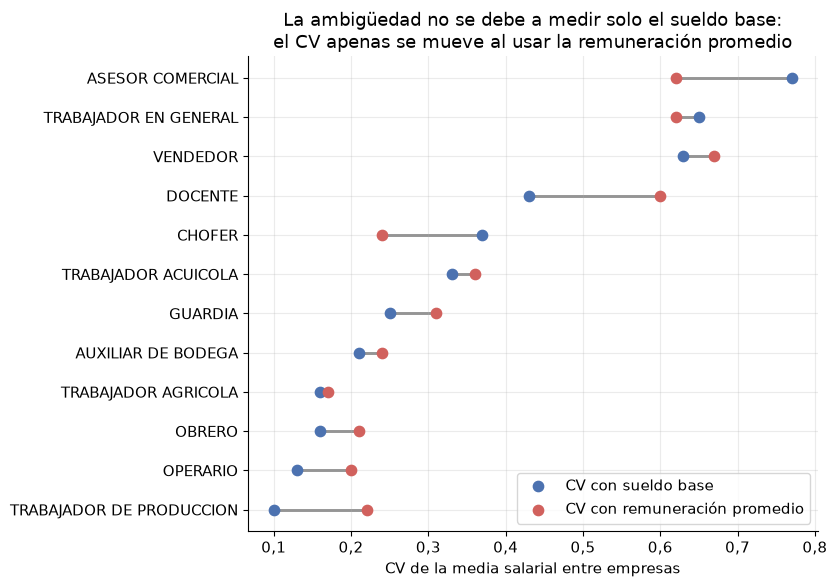

In [20]:
# CV cross-empresa: sueldo base vs remuneración promedio
sql_base_total = f"""
WITH base AS (
  SELECT empresa_identificacion emp, {NORM} cargo_norm, {SUELDO_SBU} s_sbu,
    COALESCE(remuneracion_promedio_desahucio, remuneracion_promedio_jubilacion)/({SBU_SQL}) rp_sbu
  FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL),
clean AS (SELECT * FROM base WHERE s_sbu >= {MIN_SBU} AND rp_sbu > 0 AND {CLEAN_CARGO}),
per_emp AS (SELECT cargo_norm, emp, AVG(s_sbu) m_s, AVG(rp_sbu) m_rp, COUNT(*) n
            FROM clean GROUP BY 1,2 HAVING COUNT(*) >= {MIN_GRUPO}),
freq AS (SELECT cargo_norm, SUM(n) t FROM per_emp GROUP BY 1 ORDER BY t DESC LIMIT 12)
SELECT p.cargo_norm,
  ROUND(SAFE_DIVIDE(STDDEV_SAMP(m_s),AVG(m_s)),2)  AS cv_sueldo_base,
  ROUND(SAFE_DIVIDE(STDDEV_SAMP(m_rp),AVG(m_rp)),2) AS cv_remun_promedio
FROM per_emp p JOIN freq f USING(cargo_norm)
GROUP BY 1 ORDER BY cv_sueldo_base DESC
"""
db_bt = q(sql_base_total)
display(db_bt)

# Dumbbell: CV con sueldo base vs con remuneración promedio, por cargo
d = db_bt.iloc[::-1].reset_index(drop=True)   # mayor CV arriba
y = range(len(d))
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.hlines(y, d["cv_sueldo_base"], d["cv_remun_promedio"], color=C_NEUTRO, lw=2, zorder=1)
ax.scatter(d["cv_sueldo_base"], y, color=C_ACENTO, s=55, zorder=2, label="CV con sueldo base")
ax.scatter(d["cv_remun_promedio"], y, color=C_AMBIGUA, s=55, zorder=2, label="CV con remuneración promedio")
ax.set_yticks(list(y)); ax.set_yticklabels(d["cargo_norm"])
ax.set_xlabel("CV de la media salarial entre empresas")
ax.set_title("La ambigüedad no se debe a medir solo el sueldo base:\nel CV apenas se mueve al usar la remuneración promedio")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


No baja. Salvo una caída leve en asesor comercial (0,77→0,62), el coeficiente de variación se mantiene —o incluso sube— al usar la remuneración promedio en vez del sueldo base. La ambigüedad de los cargos comerciales no es, entonces, un simple artefacto de medición: sobrevive al cambiar de variable salarial. Sigue siendo cierto, eso sí, que ninguna de las dos variables describe bien la composición del pago.


## Equidad: la brecha de género

Los datos incluyen sexo y edad, lo que permite una comprobación que además ilustra el costo de trabajar con cargos sucios. Se compara el sueldo de hombres y mujeres de dos formas: en bruto y dentro de un mismo cargo.


In [21]:
# Brecha por sexo: cruda (global) vs. dentro del mismo cargo
sql_gc = f"""
WITH c AS (SELECT UPPER(sexo_persona) sexo, {SUELDO_SBU} s
           FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL
             AND UPPER(sexo_persona) IN ("M","F") AND {SUELDO_SBU} >= {MIN_SBU})
SELECT sexo, COUNT(*) n, ROUND(APPROX_QUANTILES(s,100)[OFFSET(50)],3) mediana_sbu FROM c GROUP BY 1
"""
print("Brecha cruda (mediana, en SBU):"); display(q(sql_gc))

sql_gw = f"""
WITH base AS (SELECT UPPER(sexo_persona) sexo, {NORM} cargo_norm, {SUELDO_SBU} s
              FROM {VIEW} WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL
                AND UPPER(sexo_persona) IN ("M","F")),
c AS (SELECT * FROM base WHERE s >= {MIN_SBU} AND {CLEAN_CARGO}),
freq AS (SELECT cargo_norm, COUNT(*) n FROM c GROUP BY 1 ORDER BY n DESC LIMIT 10)
SELECT c.cargo_norm,
  COUNTIF(sexo="M") AS nM, COUNTIF(sexo="F") AS nF,
  ROUND(APPROX_QUANTILES(IF(sexo="M",s,NULL),100)[OFFSET(50)],2) med_M,
  ROUND(APPROX_QUANTILES(IF(sexo="F",s,NULL),100)[OFFSET(50)],2) med_F
FROM c JOIN freq f USING(cargo_norm)
GROUP BY 1 HAVING nM >= 30 AND nF >= 30 ORDER BY c.cargo_norm
"""
dg = q(sql_gw)
dg["brecha_%"] = ((dg["med_M"]-dg["med_F"])/dg["med_M"]*100).round(1)
print("Brecha dentro del mismo cargo (mediana M vs F, en SBU):"); display(dg)


Brecha cruda (mediana, en SBU):


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sexo,n,mediana_sbu
0,F,887643,1.277
1,M,1688219,1.140


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Brecha dentro del mismo cargo (mediana M vs F, en SBU):


,cargo_norm,nM,nF,med_M,med_F,brecha_%
0,ASESOR COMERCIAL,10645,10029,1.04,1.03,1.0
1,ASISTENTE CONTABLE,3430,11262,1.41,1.43,-1.4
2,CHOFER,19984,48,1.49,1.29,13.4
3,DOCENTE,16520,26190,1.96,1.66,15.3
4,GUARDIA,22475,1030,1.01,1.01,0.0
5,OPERARIO,12038,3090,1.03,1.02,1.0
6,TRABAJADOR ACUICOLA,17891,184,1.01,1.01,0.0
7,TRABAJADOR AGRICOLA,59133,18314,1.00,1.00,0.0
8,TRABAJADOR EN GENERAL,20180,6408,1.00,1.00,0.0
9,VENDEDOR,17895,10000,1.03,1.03,0.0


**En bruto, la mediana de las mujeres sale por encima de la de los hombres**, un resultado que sería un error leer como ausencia de brecha: refleja que hombres y mujeres se distribuyen en cargos distintos (segregación ocupacional), no que cobren igual por el mismo trabajo.

Dentro de cada cargo el panorama se ordena, con una advertencia: muchos cargos aparecen sin diferencia porque ambos sexos cobran el mínimo y sus medianas coinciden por construcción; donde hay margen sobre el piso —docente, chofer— reaparece una diferencia a favor de los hombres. Conviene tomar estas cifras como exploratorias, no como una medición cerrada: haría falta controlar por antigüedad, sector y tamaño, y verificar el tamaño de cada grupo. El punto firme es que **la brecha cruda engaña precisamente porque los cargos están sucios**: como el benchmarking, un análisis de equidad necesita primero cargos confiables.


C:\Users\pablo.encalada_actua\Documents\REPOS\ACTUALAB\salary-benchmarking\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


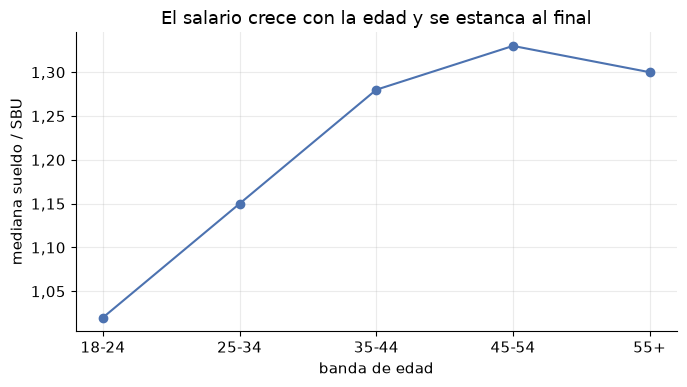

In [22]:
# Gradiente salario-edad (perfil de ciclo de vida)
sql_edad = f"""
WITH c AS (SELECT edad, {SUELDO_SBU} s FROM {VIEW}
           WHERE es_ultima_version AND sueldo IS NOT NULL AND cargo IS NOT NULL AND edad BETWEEN 18 AND 75),
c2 AS (SELECT CASE WHEN edad<25 THEN "18-24" WHEN edad<35 THEN "25-34" WHEN edad<45 THEN "35-44"
                   WHEN edad<55 THEN "45-54" ELSE "55+" END banda, s FROM c WHERE s >= {MIN_SBU})
SELECT banda, COUNT(*) n, ROUND(APPROX_QUANTILES(s,100)[OFFSET(50)],2) mediana_sbu
FROM c2 GROUP BY 1 ORDER BY 1
"""
de = q(sql_edad)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(de["banda"], de["mediana_sbu"], marker="o", color=C_ACENTO)
ax.set_ylabel("mediana sueldo / SBU"); ax.set_xlabel("banda de edad")
ax.set_title("El salario crece con la edad y se estanca al final")
plt.tight_layout(); plt.show()


El perfil por edad confirma que la antigüedad y la experiencia mueven el salario (perfil de ingresos en el sentido de Mincer, 1974): otra variable que un análisis fino de la brecha tendría que controlar.


## Conclusiones y siguiente fase

La columna de cargo, tal como viene, no sirve para comparar salarios: falta en cuatro de cada diez registros, se fragmenta en cien mil variantes y significa cosas distintas entre empresas justo en los cargos donde más se consulta un benchmark. Esa ambigüedad resistió los controles: no la explica el sector (menos del 5% de la dispersión en los cargos comerciales) ni el tamaño de la empresa (en la descomposición de varianza, por separado, el sector pesa 6% y el tamaño 0,1%) ni la antigüedad (que, descontado el efecto de trocear, aporta apenas ~0,3 puntos) ni la elección de la variable salarial (el CV se mantiene con la remuneración promedio). El desorden tampoco es inofensivo, como muestra la brecha de género distorsionada al medirla sobre cargos sucios. El alcance del resultado se limita al empleo formal privado de empresas medianas y grandes.

La implicación es reagrupar a las personas por el tipo de trabajo que realizan, con un método que no dependa de la etiqueta —inexistente para el 40%— ni use el salario como insumo del agrupamiento —para no razonar en círculo—. Ese es el objeto de la siguiente fase: un modelo de agrupamiento no supervisado, apoyado en un modelo de lenguaje para nombrar los grupos, idealmente alineados a una taxonomía ocupacional estándar como la CIUO-08 (OIT, 2008).

Este análisis le entrega a esa fase cuatro insumos: un subconjunto de datos depurado; la evidencia de que la representación debe capturar el tipo de trabajo y no el nivel de ingreso; variables de contexto para segmentar (tamaño, sector, antigüedad); y una vara de éxito —que los grupos reclasificados tengan sueldos más homogéneos por dentro que las etiquetas originales—.

Cómo respondió el análisis a cada pregunta:

| Pregunta | Respuesta | Dónde |
|---|---|---|
| P1 · calidad/cobertura del cargo | 40% sin cargo utilizable; contaminación con identificaciones | Calidad del cargo |
| P2 · ¿consistente dentro de la empresa? | Sí en su mayoría; ~2,7% colapsado (real pero acotado) | Consistencia dentro de una empresa |
| P3 · ¿consistente entre empresas? | No en los cargos genéricos/comerciales (CV 0,6–0,8) | Consistencia entre empresas |
| P4 · ¿tamaño/sector vs etiqueta? | Tamaño 0,1% y sector 6%; domina la etiqueta/empresa | Tamaño · Descomposición de varianza |
| P5 · validez externa | Empleo formal privado mediano-grande (gran empresa sobre-representada 12×) | Tamaño y validez externa |

Frentes abiertos que exceden este análisis: enlazar la nómina original para recuperar la composición del salario; un ajuste multivariante de la brecha de género (Oaxaca, 1973; Blinder, 1973) sobre cargos ya reclasificados; intervalos de confianza formales para las estimaciones; y aplicar supresión de celdas pequeñas antes de publicar resultados por subgrupos.


## Apéndice — decisiones de método

**Unidad de análisis.** Cada fila es una persona dentro de un estudio; una misma persona reaparece en años sucesivos. Se conserva `es_ultima_version = TRUE`, pero la unidad es el registro persona-año, no la persona única.

**Coeficiente de variación (CV = σ/μ; Hays, 1994).** Medida de dispersión para detectar etiquetas que agrupan roles distintos. Es sensible a valores extremos, por lo que se acota con un piso salarial y se acompaña de un análisis de sensibilidad del corte.

**Umbral CV > 0,5.** Convención; su efecto se examina variando el corte entre 0,3 y 0,7 y el tamaño mínimo de grupo entre 3 y 10. La magnitud cambia, pero el orden cualitativo (intra-empresa acotado, entre empresas severo) se mantiene.

**Normalización por SBU.** El período cubre 2016–2025, con un alza cercana al 30% en el salario mínimo; los sueldos se expresan en múltiplos del SBU del año. Hace comparables las posiciones relativas entre años; no equivale a poder adquisitivo real, pero como no se analiza tendencia de poder de compra, no afecta las conclusiones.

**Piso salarial.** Se descartan sueldos por debajo de medio SBU del año: un empleo de tiempo completo no puede pagarse bajo el mínimo legal, así que son errores o jornadas parciales.

**Normalización de texto.** El cargo se lleva a mayúsculas sin tildes; no se unifican plurales ni sinónimos, por lo que el conteo de etiquetas distintas es una cota superior.

**Privacidad.** Toda consulta termina en una agregación; ninguna celda imprime filas individuales, cédulas, nombres ni RUC. Publicar resultados por subgrupos requeriría supresión de celdas pequeñas.

**Reproducibilidad.** Las celdas se ejecutan contra BigQuery mediante credenciales de aplicación. Las cifras del texto corresponden a la ejecución del 2026-07-22; al re-ejecutar, tablas y gráficas se actualizan solas.


## Referencias

- Organización Internacional del Trabajo (2008). *Clasificación Internacional Uniforme de Ocupaciones, CIUO-08 (ISCO-08)*. Ginebra: OIT. — estándar de clasificación ocupacional; marco de referencia para la reclasificación de cargos.
- Instituto Nacional de Estadística y Censos del Ecuador (INEC). *Clasificación Nacional de Actividades Económicas (CIIU Rev. 4)* y *Encuesta Nacional de Empleo (ENEMDU)*. — sectorización y magnitud del empleo informal.
- Superintendencia de Compañías, Valores y Seguros del Ecuador (SCVS). *Directorio de compañías y estados financieros*. — fuente de tamaño y sector de empresa.
- Ecuador (2021). *Ley Orgánica de Protección de Datos Personales (LOPDP)*. Registro Oficial. — marco de tratamiento de datos personales.
- Oaxaca, R. (1973). "Male-Female Wage Differentials in Urban Labor Markets". *International Economic Review*, 14(3). — descomposición de la brecha salarial (trabajo futuro).
- Blinder, A. (1973). "Wage Discrimination: Reduced Form and Structural Estimates". *Journal of Human Resources*, 8(4).
- Hays, W. L. (1994). *Statistics* (5.ª ed.). — coeficiente de variación y ω² (omega-cuadrado) como medida de tamaño del efecto ajustada.
- Mincer, J. (1974). *Schooling, Experience, and Earnings*. NBER. — determinantes del salario (experiencia/antigüedad).

*(Referencias a completar con el formato de citación de la tesis.)*
